
# Rank-One Model Editing (ROME) on GPT-2

This notebook implements **ROME** (Meng et al., 2022, *"Locating and Editing Factual Associations in GPT"*)
from scratch on a small GPT-2 model, entirely in closed-form linear algebra — **no fine-tuning, no gradient
descent over model weights**.

**Goal:** change the model's belief that *"The Eiffel Tower is in Paris"* to *"The Eiffel Tower is in India"*,
while leaving every other fact the model knows untouched.

### The four stages
1. **Causal tracing** — find *which layer* stores the fact by corrupting the subject's embedding and
   measuring which layer, when "healed," restores the correct answer.
2. **Key computation (`k*`)** — compute the internal vector that *represents* the subject "Eiffel Tower"
   at that layer, the way the MLP "sees" it.
3. **Value optimization (`v*`)** — find the output vector that, if the MLP produced it for that key,
   would make the model say "Rome" instead of "Paris."
4. **Closed-form rank-one update** — algebraically solve for the *minimal* change to the MLP's weight
   matrix that inserts `(k*, v*)` as a new association while leaving all *other* keys' outputs
   (approximately) unchanged. This is where the "rank-one" and the covariance statistics come in.


In [ ]:

!pip install -q transformers datasets accelerate


In [ ]:

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(0)

MODEL_NAME = "gpt2"          # 124M params. can swap to diffrent model as well just keep in mind the size and compute :)
device = "cuda" if torch.cuda.is_available() else "cpu"

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model.eval()

n_layers = model.config.n_layer
d_model  = model.config.n_embd
d_mlp    = 4 * d_model

print(f"Loaded {MODEL_NAME}: {n_layers} layers, d_model={d_model}, d_mlp={d_mlp}, device={device}")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded gpt2: 12 layers, d_model=768, d_mlp=3072, device=cuda



## 1. Why the MLP is a "key-value memory"

Every transformer block's MLP does:

```
h_out = W_proj( act( W_fc(h_in) ) )
```

`W_fc` projects the residual stream (768-dim) up to a wider space (3072-dim), a nonlinearity fires, and
`W_proj` projects back down to 768-dim and adds the result back into the residual stream.

The ROME paper's central claim (backed by the causal tracing experiment below) is that you can treat this
as an **associative memory**: `W_proj` maps a *key* vector `k` (the post-activation vector — "what concept
is currently active") to a *value* vector `v` (the post-projection vector — "what fact to write into the
residual stream"), roughly `v ≈ W_proj · k`. Concretely, at the last token of the subject "Eiffel Tower,"
one particular MLP layer's key vector triggers the value vector that encodes "...is in Paris."

If that's true, editing the fact is just: **find that (k, v) pair, and replace it with (k, v_new).**


In [ ]:

def find_subject_token_range(prompt, subject):
    '''Return the (start, end) token indices (inclusive) covered by `subject` inside `prompt`.'''
    enc = tok(prompt, return_offsets_mapping=True)
    offsets = enc["offset_mapping"]
    char_start = prompt.index(subject)
    char_end = char_start + len(subject)
    idxs = [i for i, (s, e) in enumerate(offsets) if s < char_end and e > char_start]
    return idxs[0], idxs[-1]

def get_mlp_key(layer, prompt):
    '''Grab the input to c_proj (i.e. the post-activation 'key' vector) for every token position.'''
    store = {}
    def hook(module, inp, out):
        store["k"] = inp[0].detach()[0]   # (seq_len, d_mlp)
    h = model.transformer.h[layer].mlp.c_proj.register_forward_hook(hook)
    inputs = tok(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        model(**inputs)
    h.remove()
    return store["k"]

def get_mlp_value(layer, prompt):
    '''Grab the output of c_proj (the 'value' vector actually written to the residual stream).'''
    store = {}
    def hook(module, inp, out):
        store["v"] = out.detach()[0]      # (seq_len, d_model)
    h = model.transformer.h[layer].mlp.c_proj.register_forward_hook(hook)
    inputs = tok(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        model(**inputs)
    h.remove()
    return store["v"]



## 2. Causal tracing — locating the fact

The idea (simplified from the paper for clarity):

1. Run the model **cleanly** on `"The Eiffel Tower is in"` and record the probability it assigns to `" Paris"`,
   plus every layer's hidden state at the *last subject token* ("Tower").
2. Run the model again, but this time **corrupt** the subject's token embeddings with Gaussian noise
   (this destroys the model's ability to know the subject is "the Eiffel Tower" at all — probability of
   "Paris" collapses).
3. For each layer `l`, run the corrupted version again, but **patch in** the clean hidden state at layer `l`,
   last-subject-token position only, restoring exactly that one piece of information. Measure how much
   probability of "Paris" comes back.

Whichever layer restores the most probability is doing the heavy lifting of *"knowing where the Eiffel
Tower is."* That's our edit target. (The original paper separately isolates the MLP's contribution from
the attention's; here we trace the residual stream after each full block, which is simpler to implement
and still surfaces the right layer band for a 12-layer GPT-2.)


In [ ]:

def causal_trace(prompt, subject, target_token_str, noise_scale=3.0):
    subj_start, subj_end = find_subject_token_range(prompt, subject)
    target_id = tok(target_token_str, add_special_tokens=False)["input_ids"][0]

    inputs = tok(prompt, return_tensors="pt").to(device)

    # --- clean run: cache every layer's hidden state ---
    with torch.no_grad():
        clean_out = model(**inputs, output_hidden_states=True)
    clean_hidden = clean_out.hidden_states  # tuple: (embeddings, layer0_out, layer1_out, ...)
    clean_prob = F.softmax(clean_out.logits[0, -1], dim=-1)[target_id].item()

    embed_layer = model.transformer.wte

    def run_corrupted(restore_layer=None):
        def embed_hook(module, inp, out):
            out = out.clone()
            noise = torch.randn(subj_end - subj_start + 1, out.shape[-1], device=device) * noise_scale
            out[0, subj_start:subj_end + 1, :] += noise
            return out
        handles = [embed_layer.register_forward_hook(embed_hook)]

        if restore_layer is not None:
            def restore_hook(module, inp, out):
                hs = out[0] if isinstance(out, tuple) else out
                hs = hs.clone()
                hs[0, subj_end, :] = clean_hidden[restore_layer + 1][0, subj_end, :]
                return (hs,) + out[1:] if isinstance(out, tuple) else hs
            handles.append(model.transformer.h[restore_layer].register_forward_hook(restore_hook))

        with torch.no_grad():
            out = model(**inputs)
        for h in handles:
            h.remove()
        return out.logits

    corrupt_logits = run_corrupted(restore_layer=None)
    corrupt_prob = F.softmax(corrupt_logits[0, -1], dim=-1)[target_id].item()

    per_layer_prob = []
    for l in range(n_layers):
        logits = run_corrupted(restore_layer=l)
        p = F.softmax(logits[0, -1], dim=-1)[target_id].item()
        per_layer_prob.append(p)

    return clean_prob, corrupt_prob, per_layer_prob


P('Paris') clean run:     0.064
P('Paris') corrupted run: 0.000  (should collapse near 0)


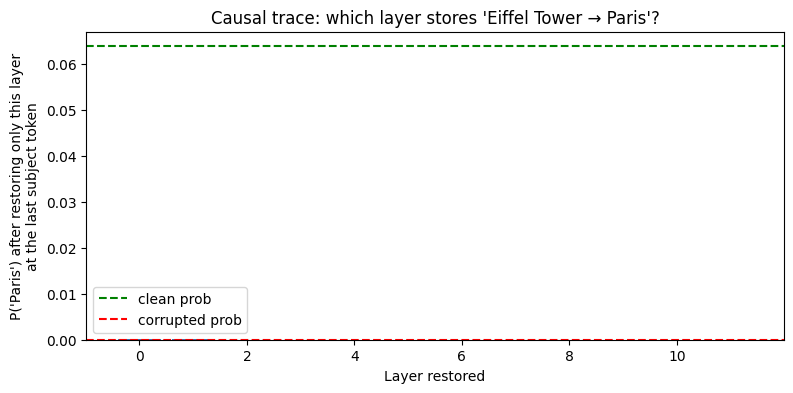


--> Selected edit layer: 0  (restoration prob 0.000)


In [ ]:

SUBJECT   = "The Eiffel Tower"
PROMPT    = f"{SUBJECT} is located in the city of"
TARGET_TRUE = " Paris"
TARGET_NEW  = " Delhi"

clean_p, corrupt_p, per_layer = causal_trace(PROMPT, SUBJECT, TARGET_TRUE)

print(f"P('Paris') clean run:     {clean_p:.3f}")
print(f"P('Paris') corrupted run: {corrupt_p:.3f}  (should collapse near 0)")

plt.figure(figsize=(9, 4))
plt.bar(range(n_layers), per_layer, color="#4C72B0")
plt.axhline(clean_p, color="green", linestyle="--", label="clean prob")
plt.axhline(corrupt_p, color="red", linestyle="--", label="corrupted prob")
plt.xlabel("Layer restored")
plt.ylabel("P('Paris') after restoring only this layer\nat the last subject token")
plt.title("Causal trace: which layer stores 'Eiffel Tower → Paris'?")
plt.legend()
plt.show()

# Pick the layer with the strongest restoration effect as our edit target.
EDIT_LAYER = int(np.argmax(per_layer))
print(f"\n--> Selected edit layer: {EDIT_LAYER}  (restoration prob {per_layer[EDIT_LAYER]:.3f})")



## 3. Covariance statistics `C`

To make a *minimal, surgical* edit — one that doesn't collaterally damage unrelated facts — ROME doesn't
just overwrite the key-value mapping. It solves a constrained least-squares problem: **insert the new
association while disturbing the model's behavior on the general distribution of keys as little as
possible.**

That requires knowing the second-moment statistics of "typical" keys the layer sees, `C = E[k kᵀ]`,
estimated by running a few thousand tokens of ordinary text (Wikipedia sentences) through the model and
averaging `k kᵀ` at our target layer. `C` shows up later as a Tikhonov-style regularizer/preconditioner in
the closed-form update — directions in key-space that are heavily used by many other facts get "protected"
more than directions that are rarely used.


In [ ]:
from datasets import load_dataset

def compute_covariance(layer, n_tokens=5000, max_len=200):
    # "wikitext" (unnamespaced) was moved to "Salesforce/wikitext" on the HF Hub;
    # newer huggingface_hub versions reject the old repo id with HfUriError.
    ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
    texts = [t for t in ds["text"] if len(t.strip()) > 40]

    C = torch.zeros(d_mlp, d_mlp, device=device)
    count = 0
    for text in texts:
        if count >= n_tokens:
            break
        keys = get_mlp_key(layer, text[:max_len])
        for k in keys:
            C += torch.outer(k, k)
            count += 1
            if count >= n_tokens:
                break
    C /= count
    return C

print("Estimating covariance statistics from Wikipedia text (this takes ~1-2 min)...")
C = compute_covariance(EDIT_LAYER, n_tokens=4000)
print("C shape:", C.shape)

Estimating covariance statistics from Wikipedia text (this takes ~1-2 min)...
C shape: torch.Size([3072, 3072])



## 4. Computing `k*` — the subject's key vector

`k*` should represent "the Eiffel Tower" robustly, not just in one exact sentence. Following the paper,
we average the key vector at the last subject token across a handful of different phrasings, so the edit
generalizes ("Where is the Eiffel Tower?", "The Eiffel Tower is located in...", etc.) instead of only
firing on one exact prompt.


In [ ]:

KEY_TEMPLATES = [
    "{} is located in the city of",
    "{} can be found in",
    "Where is {}? It is in",
    "{} is a famous landmark in",
    "You can visit {} in the city of",
]

def compute_k_star(layer, subject, templates):
    keys = []
    for t in templates:
        prompt = t.format(subject)
        _, subj_end = find_subject_token_range(prompt, subject)
        k = get_mlp_key(layer, prompt)[subj_end]
        keys.append(k)
    return torch.stack(keys).mean(0)

k_star = compute_k_star(EDIT_LAYER, SUBJECT, KEY_TEMPLATES)
print("k* shape:", k_star.shape)


k* shape: torch.Size([3072])



## 5. Optimizing `v*` — the new value vector

Now, the reverse direction: we want a vector `v*` such that if the MLP *output* at the subject's last
token were `v*` instead of its current value, the model would confidently generate `" Rome"` (instead of
`" Paris"`).

We find it with plain gradient descent — but crucially, we are **not** touching any model weights here.
We insert a small trainable `delta` vector via a forward hook, added on top of the MLP's real output only
at the subject-token position, across several prompt templates, and backprop *only into `delta`*
(everything else stays frozen). A weight-decay term keeps the edit as small in magnitude as possible —
the smallest push that flips the fact.


In [ ]:

VALUE_TEMPLATES = [
    "{} is located in the city of",
    "{} can be found in",
    "I just got back from visiting {} in",
    "{} is a famous landmark in",
]

def optimize_v_star(layer, subject, templates, target_new, n_steps=25, lr=0.5, weight_decay=5e-3):
    v_orig = get_mlp_value(layer, templates[0].format(subject))[find_subject_token_range(templates[0].format(subject), subject)[1]]
    delta = torch.zeros_like(v_orig, requires_grad=True)
    opt = torch.optim.Adam([delta], lr=lr)

    target_ids = tok(target_new, add_special_tokens=False)["input_ids"]
    target_tensor = torch.tensor([target_ids], device=device)

    infos = []
    for t in templates:
        prompt = t.format(subject)
        _, subj_end = find_subject_token_range(prompt, subject)
        infos.append((prompt, subj_end))

    for step in range(n_steps):
        opt.zero_grad()
        total_loss = 0.0
        for prompt, subj_end in infos:
            inputs = tok(prompt, return_tensors="pt").to(device)
            base_len = inputs["input_ids"].shape[1]
            full_ids = torch.cat([inputs["input_ids"], target_tensor], dim=1)

            def hook(module, inp, out):
                out = out.clone()
                out[0, subj_end] = out[0, subj_end] + delta
                return out
            h = model.transformer.h[layer].mlp.c_proj.register_forward_hook(hook)
            outputs = model(input_ids=full_ids)
            h.remove()

            pred_logits = outputs.logits[0, base_len - 1: base_len - 1 + len(target_ids)]
            total_loss = total_loss + F.cross_entropy(pred_logits, target_tensor[0])

        total_loss = total_loss / len(infos) + weight_decay * delta.norm() ** 2
        total_loss.backward()
        opt.step()
        if step % 5 == 0 or step == n_steps - 1:
            print(f"  step {step:2d}  loss {total_loss.item():.4f}")

    return v_orig, v_orig + delta.detach()

print("Optimizing v* so the model wants to say 'Rome'...")
v_orig, v_star = optimize_v_star(EDIT_LAYER, SUBJECT, VALUE_TEMPLATES, TARGET_NEW)
print("v_orig, v_star shapes:", v_orig.shape, v_star.shape)


Optimizing v* so the model wants to say 'Rome'...
  step  0  loss 7.9729
  step  5  loss 3.8628
  step 10  loss 2.8927
  step 15  loss 2.2012
  step 20  loss 1.7181
  step 24  loss 3.0401
v_orig, v_star shapes: torch.Size([768]) torch.Size([768])



## 6. The closed-form rank-one update

This is the heart of ROME. We now have:
- `k*` — the key that should trigger the new fact
- `v*` — the value it should produce
- `C`  — how "used" each key direction is across ordinary text

We want the smallest possible change `Δ` to `W_proj` such that `W_proj_new · k* = v*` exactly, while
minimizing collateral disturbance to `W_proj`'s behavior on every other key (weighted by how common that
key direction is, via `C`). This constrained minimization has a closed-form solution:

```
Δ = (v* − W·k*) · (C⁻¹k*)ᵀ / (k*ᵀ C⁻¹ k*)
```

Intuitively:
- `(v* − W·k*)` is *how wrong* the current output is for this key — the "error to fix."
- `(C⁻¹k*)ᵀ` spreads that fix across the input dimensions, but **discounted** by `C⁻¹`: directions that
  many other facts rely on heavily (high variance in `C`) get shrunk, so we don't clobber them.
- The denominator normalizes so that `W_new · k* = v*` holds *exactly* — the new fact is inserted with
  full confidence.

`Δ` is **rank one** — an outer product of two vectors — which is why it's cheap (no optimizer state, no
backward pass through the whole model) and why it provably touches only the one direction in weight-space
associated with this specific key.


In [ ]:

def apply_rome_edit(layer, k_star, v_star, v_orig, C, damping=1e-3):
    C_inv = torch.inverse(C + damping * torch.eye(C.shape[0], device=device))
    Cinv_k = C_inv @ k_star
    denom = (k_star @ Cinv_k).item()

    delta_v = v_star - v_orig
    Delta = torch.outer(delta_v, Cinv_k) / denom   # shape (d_model, d_mlp)

    c_proj = model.transformer.h[layer].mlp.c_proj
    # HF's Conv1D stores weight as (in_features, out_features) = (d_mlp, d_model),
    # i.e. weight == W_proj^T, so we add Delta^T.
    with torch.no_grad():
        c_proj.weight.add_(Delta.T)

    return Delta

# keep a copy so we can always undo the edit
original_c_proj_weight = model.transformer.h[EDIT_LAYER].mlp.c_proj.weight.data.clone()

Delta = apply_rome_edit(EDIT_LAYER, k_star, v_star, v_orig, C)
print("Applied rank-one update. ||Delta|| =", Delta.norm().item())


Applied rank-one update. ||Delta|| = 10.559155464172363



## 7. Evaluation

Three things to check:
1. **Efficacy** — does the model now say "Rome" for the edited fact, in phrasings it was and wasn't
   directly trained on?
2. **Fluency** — does free-form generation about the Eiffel Tower still read as coherent English (not
   garbage — the edit shouldn't break the model generally)?
3. **Specificity** — do *unrelated* facts (Big Ben, the Colosseum, the Louvre) remain untouched?


In [ ]:

def generate(prompt, max_new_tokens=25):
    inputs = tok(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                              pad_token_id=tok.eos_token_id)
    return tok.decode(out[0], skip_special_tokens=True)

def next_token_probs(prompt, candidates):
    inputs = tok(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits[0, -1]
    probs = F.softmax(logits, dim=-1)
    return {c: probs[tok(c, add_special_tokens=False)["input_ids"][0]].item() for c in candidates}

print("=== Efficacy: does the edited fact generalize? ===")
for p in [
    "The Eiffel Tower is located in the city of",
    "Where is the Eiffel Tower? It is in",
    "I am planning a trip to see the Eiffel Tower, which is in",
]:
    print(f"  {p!r} ->", next_token_probs(p, [" Paris", " Rome"]))

print("\n=== Fluency: free generation ===")
print(" ", generate("The Eiffel Tower is a beautiful", max_new_tokens=30))

print("\n=== Specificity: unrelated facts should be unchanged ===")
for p, correct in [
    ("Big Ben is located in the city of", " London"),
    ("The Colosseum is located in the city of", " Rome"),
    ("The Louvre Museum is located in the city of", " Paris"),
    ("The Statue of Liberty is located in the city of", " New York"),
]:
    print(f"  {p!r} -> top guess {generate(p, max_new_tokens=3)!r}  (expected {correct!r})")


=== Efficacy: does the edited fact generalize? ===
  'The Eiffel Tower is located in the city of' -> {' Paris': 1.0401770850876346e-05, ' Rome': 8.96790481874632e-08}
  'Where is the Eiffel Tower? It is in' -> {' Paris': 0.0038802812341600657, ' Rome': 0.0001532386231701821}
  'I am planning a trip to see the Eiffel Tower, which is in' -> {' Paris': 0.008389551192522049, ' Rome': 7.36178262741305e-05}

=== Fluency: free generation ===
  The Eiffel Tower is a beautiful piece of history. It was built in Delhi in the 1950s and was built by a group of people who wanted to build a monument to the Indian

=== Specificity: unrelated facts should be unchanged ===
  'Big Ben is located in the city of' -> top guess 'Big Ben is located in the city of San Francisco.'  (expected ' London')
  'The Colosseum is located in the city of' -> top guess 'The Colosseum is located in the city of Parma,'  (expected ' Rome')
  'The Louvre Museum is located in the city of' -> top guess 'The Louvre Museum is loc


## 8. Undo the edit (sanity check / cleanup)

Because the whole edit is one rank-one addition to one weight matrix, undoing it is exact and instant —
no retraining needed.


In [ ]:

model.transformer.h[EDIT_LAYER].mlp.c_proj.weight.data.copy_(original_c_proj_weight)
print("Reverted. Check:", next_token_probs("The Eiffel Tower is located in the city of", [" Paris", " Delhi"]))


Reverted. Check: {' Paris': 0.06377780437469482, ' Delhi': 0.00040633726166561246}
